In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from random import randint

import shap
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, average_precision_score, confusion_matrix, roc_curve, auc

In [2]:
# ── 1. Load and Clean Master Feature Matrix ───────────────────────────────────
DATA_DIR = "../data/processed"
MASTER_CSV = os.path.join(DATA_DIR, "master_features.csv")

if not os.path.exists(MASTER_CSV):
    # Fallback to current folder if relative directory is structured differently
    MASTER_CSV = "master_features.csv"

print(f"Loading Master Feature Matrix: '{MASTER_CSV}'...")
df = pd.read_csv(MASTER_CSV)
df['earnings_date'] = pd.to_datetime(df['earnings_date'])


Loading Master Feature Matrix: '../data/processed/master_features.csv'...


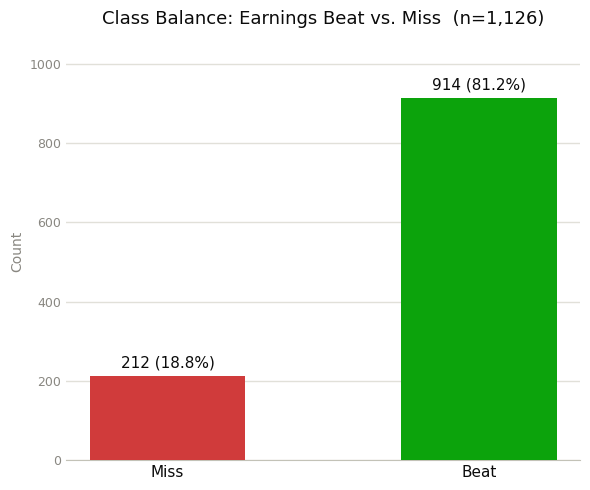

In [3]:
# ── Class Balance: Earnings Beat vs. Miss ──────────────────────────────────────
counts = df['target_label'].value_counts().sort_index()  # index 0 = Miss, 1 = Beat
labels = ['Miss', 'Beat']
values = [counts.get(0, 0), counts.get(1, 0)]
pct = [v / sum(values) * 100 for v in values]

STATUS_CRITICAL = '#d03b3b'  # Miss
STATUS_GOOD = '#0ca30c'      # Beat
INK_PRIMARY = '#0b0b0b'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(labels, values, width=0.5, color=[STATUS_CRITICAL, STATUS_GOOD], zorder=3)

# Direct labels: count + share, at the tip of each bar
for bar, v, p in zip(bars, values, pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.015,
            f"{v:,} ({p:.1f}%)", ha='center', va='bottom',
            fontsize=11, color=INK_PRIMARY, fontweight='medium')

# Recessive gridlines behind the bars, clean y-ticks
ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, max(values) * 1.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(BASELINE)

ax.tick_params(axis='x', colors=INK_PRIMARY, labelsize=11, length=0)
ax.tick_params(axis='y', colors=INK_MUTED, labelsize=9, length=0)

ax.set_ylabel('Count', color=INK_MUTED, fontsize=10)
ax.set_title(f'Class Balance: Earnings Beat vs. Miss  (n={sum(values):,})',
             fontsize=13, color=INK_PRIMARY, pad=14)

plt.tight_layout()
plt.show()


In [4]:
# ── 2. Time-Based Stratified Split (Preventing Time Leakage) ──────────────────
# Rather than standard random train_test_split (which leaks future data),
# we split chronologically. Train: 2021 to mid-2025 | Test: late-2025 to 2026.
# %%
SPLIT_DATE = pd.to_datetime("2025-07-01")

# Chronological partition
train_df = df[df['earnings_date'] < SPLIT_DATE].copy()
test_df = df[df['earnings_date'] >= SPLIT_DATE].copy()

# Print out statistics
print(f"📊 Training Set (2021 - Mid 2025): {len(train_df)} rows")
print(f"📊 Testing Set (Late 2025 - 2026): {len(test_df)} rows")

# Verify base rates (Naive Benchmark of always predicting a "Beat" / Y=1)
train_base_rate = (train_df['target_label'] == 1).mean() * 100
test_base_rate = (test_df['target_label'] == 1).mean() * 100

print(f"\n📢 Naive Baseline Strategy ('Always Guess Beat' Accuracy):")
print(f"  -> Train Set Base Rate: {train_base_rate:.2f}%")
print(f"  -> Test Set Base Rate:  {test_base_rate:.2f}%")

📊 Training Set (2021 - Mid 2025): 872 rows
📊 Testing Set (Late 2025 - 2026): 254 rows

📢 Naive Baseline Strategy ('Always Guess Beat' Accuracy):
  -> Train Set Base Rate: 79.70%
  -> Test Set Base Rate:  86.22%


In [5]:

# Define feature groupings based on engineered variables
price_features = [
    'rsi_14_at_T1', 'macd_hist_at_T1', 'px_vs_sma20_T1', 'px_vs_sma10_T1', 'ret_14d', 'rsi_mean',
      'rsi_slope', 'vol_mean', 'vol_ratio_mean', 'ret_std_14d'
]
text_features = ['finbert_avg_sentiment']
surprise_features = ['avg_surprise_pct_last4', 'beat_rate_last4', 'surprise_pct_last_q', 'beat_streak']
multimodal_features = price_features + text_features + surprise_features


print(price_features)

['rsi_14_at_T1', 'macd_hist_at_T1', 'px_vs_sma20_T1', 'px_vs_sma10_T1', 'ret_14d', 'rsi_mean', 'rsi_slope', 'vol_mean', 'vol_ratio_mean', 'ret_std_14d']


In [6]:
# Isolate Y labels
y_train = train_df['target_label']
y_test = test_df['target_label']

In [7]:
scaler = StandardScaler()
scaler_surprise = StandardScaler()

# Scaled Training Features
X_train_price = scaler.fit_transform(train_df[price_features])
X_train_text  = train_df[text_features].values # Sentiment is already naturally bounded between [-1, 1]
X_train_surprise = scaler_surprise.fit_transform(train_df[surprise_features])  # beat_streak etc. aren't bounded like sentiment, so scale them too
X_train_multi = np.hstack((X_train_price, X_train_text, X_train_surprise))

# Scaled Testing Features
X_test_price = scaler.transform(test_df[price_features])
X_test_text  = test_df[text_features].values
X_test_surprise = scaler_surprise.transform(test_df[surprise_features])
X_test_multi = np.hstack((X_test_price, X_test_text, X_test_surprise))

# Convert back to dataframes for easy SHAP processing later
X_train_multi_df = pd.DataFrame(X_train_multi, columns=multimodal_features)
X_test_multi_df = pd.DataFrame(X_test_multi, columns=multimodal_features)

print("✅ Data scaled and isolated successfully. Features ready for training.")


✅ Data scaled and isolated successfully. Features ready for training.


In [8]:
# %% [markdown]
# ## 4. Training the Comparative Pipeline
# We train three distinct models to isolate the predictive contributions of each data stream:
# - **Model A (Price-Only):** Uses numerical indicators to model technical market expectations.
# - **Model B (Text-Only):** Uses FinBERT sentiment scores to model linguistic media sentiment.
# - **Model C (Multimodal):** Fuses all three streams (price, text, earnings-surprise history) to exploit cross-modality signals.

# %%
# Define classifiers with fixed random states for academic reproducibility
# class_weight='balanced' counteracts the ~91/9 class imbalance in target_label,
# and scoring='roc_auc' (rather than 'accuracy') prevents GridSearchCV from
# picking hyperparameters that just collapse to predicting the majority class.

# train_df's rows are grouped in contiguous per-ticker blocks (all of one
# ticker's events, then the next), not interleaved. Plain cv=5 uses
# StratifiedKFold(shuffle=False), so folds would be built from whichever
# tickers happen to fall in that slice of the array instead of a
# representative cross-section of all tickers. Shuffle explicitly so each
# fold mixes tickers fairly.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_price = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
rf_text =  RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
rf_multi = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

grid_search_price = GridSearchCV(
    estimator=rf_price, 
    param_grid=param_grid, 
    cv=cv_strategy, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1
)

grid_search_text = GridSearchCV(
    estimator=rf_text, 
    param_grid=param_grid, 
    cv=cv_strategy, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1
)
grid_search_multi = GridSearchCV(
    estimator=rf_multi, 
    param_grid=param_grid, 
    cv=cv_strategy, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1
)

print("⏳ Training Model A (Price-Only Random Forest)...")
grid_search_price.fit(X_train_price, y_train)
print("Best Parameters:", grid_search_price.best_params_)
print("Best Cross-Validation Score:", grid_search_price.best_score_)

print("⏳ Training Model B (Text-Only Random Forest)...")
grid_search_text.fit(X_train_text, y_train)
print("Best Parameters:", grid_search_text.best_params_)
print("Best Cross-Validation Score:", grid_search_text.best_score_)

print("⏳ Training Model C (Multimodal Random Forest Classifier)...")
grid_search_multi.fit(X_train_multi_df, y_train)
print("Best Parameters:", grid_search_multi.best_params_)
print("Best Cross-Validation Score:", grid_search_multi.best_score_)

print("🏆 Training phase complete!")

⏳ Training Model A (Price-Only Random Forest)...
Fitting 5 folds for each of 162 candidates, totalling 810 fits


Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best Cross-Validation Score: 0.5551969852689277
⏳ Training Model B (Text-Only Random Forest)...
Fitting 5 folds for each of 162 candidates, totalling 810 fits


Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Best Cross-Validation Score: 0.5091715199269157
⏳ Training Model C (Multimodal Random Forest Classifier)...
Fitting 5 folds for each of 162 candidates, totalling 810 fits


Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross-Validation Score: 0.6469453009021354
🏆 Training phase complete!


In [9]:
# %% [markdown]
# ## 4b. Logistic Regression Baseline
# The Random Forests above were never checked against a plain linear model. If a much
# simpler, much faster Logistic Regression does just as well, the Random Forest's extra
# complexity isn't earning its keep. Same features, same time-based split, same CV
# strategy and scoring — the only thing that changes is the model.

# %%
logreg_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

lr_price = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_text = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_multi = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)

grid_search_lr_price = GridSearchCV(lr_price, logreg_param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
grid_search_lr_text = GridSearchCV(lr_text, logreg_param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
grid_search_lr_multi = GridSearchCV(lr_multi, logreg_param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)

print("⏳ Training Logistic Regression (Price-Only)...")
grid_search_lr_price.fit(X_train_price, y_train)
print("Best C:", grid_search_lr_price.best_params_['C'], "| Best CV ROC-AUC:", grid_search_lr_price.best_score_)

print("⏳ Training Logistic Regression (Text-Only)...")
grid_search_lr_text.fit(X_train_text, y_train)
print("Best C:", grid_search_lr_text.best_params_['C'], "| Best CV ROC-AUC:", grid_search_lr_text.best_score_)

print("⏳ Training Logistic Regression (Multimodal)...")
grid_search_lr_multi.fit(X_train_multi_df, y_train)
print("Best C:", grid_search_lr_multi.best_params_['C'], "| Best CV ROC-AUC:", grid_search_lr_multi.best_score_)

print("🏆 Logistic Regression baseline training complete!")

⏳ Training Logistic Regression (Price-Only)...


Best C: 100 | Best CV ROC-AUC: 0.49730615507593934
⏳ Training Logistic Regression (Text-Only)...
Best C: 0.001 | Best CV ROC-AUC: 0.483628525750828
⏳ Training Logistic Regression (Multimodal)...
Best C: 0.1 | Best CV ROC-AUC: 0.5924083590270641
🏆 Logistic Regression baseline training complete!


In [10]:
# %% [markdown]
# ## 5. Quantitative Model Comparison & Scorekeeping

# %%
models = {
    "Model A: Price-Only (RF)": (grid_search_price.best_estimator_, X_test_price),
    "Model B: Text-Only (RF)":  (grid_search_text.best_estimator_,  X_test_text),
    "Model C: Multimodal (RF)": (grid_search_multi.best_estimator_, X_test_multi_df),
    "Model D: Price-Only (LogReg)": (grid_search_lr_price.best_estimator_, X_test_price),
    "Model E: Text-Only (LogReg)":  (grid_search_lr_text.best_estimator_,  X_test_text),
    "Model F: Multimodal (LogReg)": (grid_search_lr_multi.best_estimator_, X_test_multi_df),
}
results_matrix = []

for name, (model, X_test) in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, preds)
    bal_acc = balanced_accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    pr_auc = average_precision_score(y_test, probs)
    
    results_matrix.append({
        "Model": name,
        "Accuracy": f"{acc * 100:.2f}%",
        "Balanced Acc": f"{bal_acc * 100:.2f}%",
        "Precision": f"{prec * 100:.2f}%",
        "Recall": f"{rec * 100:.2f}%",
        "F1-Score": f"{f1 * 100:.2f}%",
        "ROC-AUC": f"{roc_auc:.4f}",
        "PR-AUC": f"{pr_auc:.4f}"
    })


In [11]:
# Add the Naive Benchmark for explicit contrast
naive_preds = np.ones(len(y_test)) # Predict beat (1) every time
results_matrix.append({
    "Model": "Naive Baseline (Guess Beat)",
    "Accuracy": f"{test_base_rate:.2f}%",
    "Balanced Acc": f"{balanced_accuracy_score(y_test, naive_preds) * 100:.2f}%",
    "Precision": f"{test_base_rate:.2f}%",
    "Recall": "100.00%",
    "F1-Score": f"{f1_score(y_test, naive_preds) * 100:.2f}%",
    "ROC-AUC": "0.5000",
    "PR-AUC": f"{average_precision_score(y_test, naive_preds):.4f}"
})


In [12]:
# Display comparative dataframe
df_comparison = pd.DataFrame(results_matrix)
print("\n=== SYSTEM PERFORMANCE COMPARISON SCORECARD ===")
print(df_comparison.to_string(index=False))


=== SYSTEM PERFORMANCE COMPARISON SCORECARD ===
                       Model Accuracy Balanced Acc Precision  Recall F1-Score ROC-AUC PR-AUC
    Model A: Price-Only (RF)   75.59%       53.44%    87.20%  84.02%   85.58%  0.5618 0.8836
     Model B: Text-Only (RF)   64.57%       59.05%    89.57%  66.67%   76.44%  0.5577 0.8852
    Model C: Multimodal (RF)   79.53%       62.92%    89.95%  85.84%   87.85%  0.6918 0.9316
Model D: Price-Only (LogReg)   51.18%       52.49%    87.40%  50.68%   64.16%  0.4915 0.8428
 Model E: Text-Only (LogReg)   32.28%       36.73%    77.01%  30.59%   43.79%  0.3465 0.8026
Model F: Multimodal (LogReg)   68.50%       67.33%    92.64%  68.95%   79.06%  0.7143 0.9129
 Naive Baseline (Guess Beat)   86.22%       50.00%    86.22% 100.00%   92.60%  0.5000 0.8622


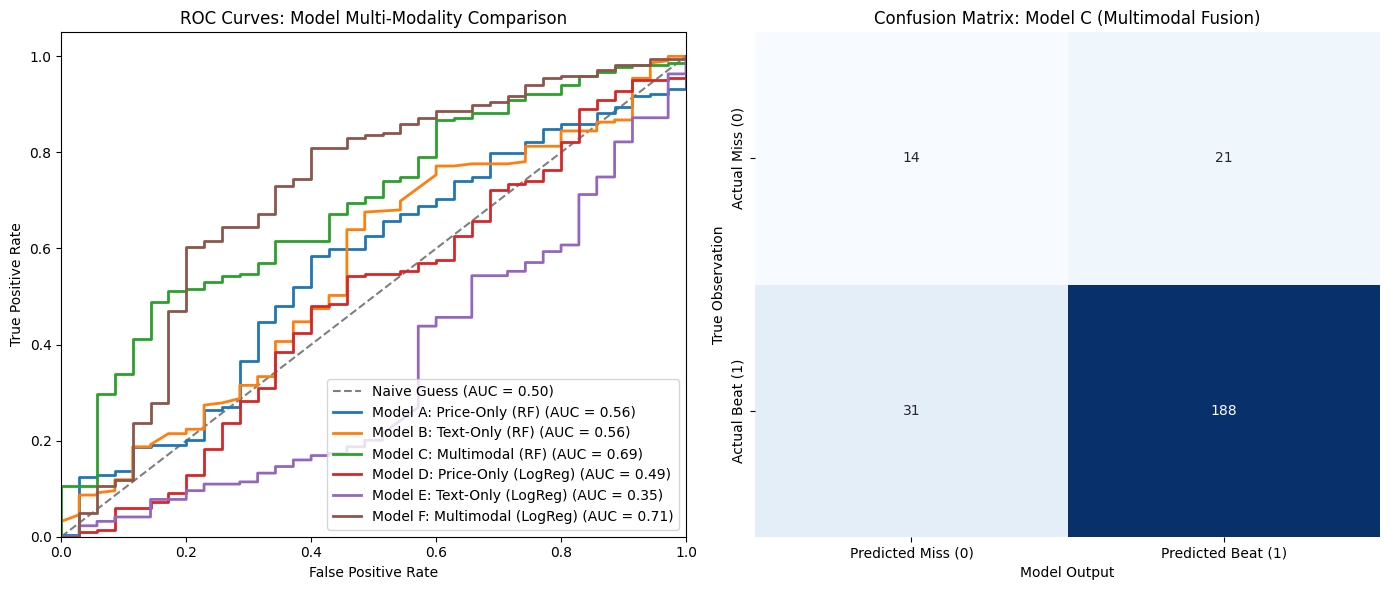

In [13]:
# ## 6. Visualizing Performance Results (Confusion Matrix & ROC-AUC)

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot A: ROC Curves
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Naive Guess (AUC = 0.50)")
for name, (model, X_test) in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})", linewidth=2)

ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves: Model Multi-Modality Comparison')
ax1.legend(loc="lower right")

# Plot B: Confusion Matrix (Multimodal Model)
# Use the fitted best_estimator_, not the raw rf_multi passed into GridSearchCV
# (GridSearchCV clones the estimator internally, so rf_multi itself is never fit).
multi_preds = grid_search_multi.best_estimator_.predict(X_test_multi_df)
cm = confusion_matrix(y_test, multi_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False,
            xticklabels=['Predicted Miss (0)', 'Predicted Beat (1)'],
            yticklabels=['Actual Miss (0)', 'Actual Beat (1)'])
ax2.set_title('Confusion Matrix: Model C (Multimodal Fusion)')
ax2.set_ylabel('True Observation')
ax2.set_xlabel('Model Output')

plt.tight_layout()
plt.show()



⏳ Initializing SHAP tree-based explainer...


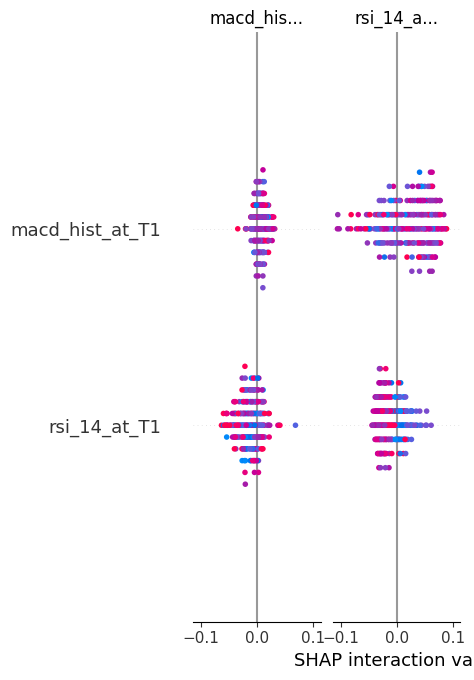

Text(0.5, 1.0, 'SHAP Feature Importance: Explaining Earnings Surprises (Class 1: Beat)')

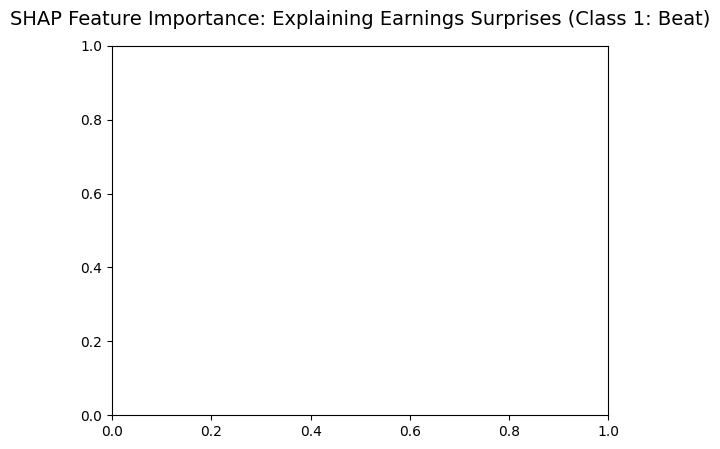

In [14]:
print("\n⏳ Initializing SHAP tree-based explainer...")
explainer = shap.TreeExplainer(grid_search_multi.best_estimator_)
shap_values = explainer.shap_values(X_test_multi_df)

# SHAP values in scikit-learn random forests return a list for each class. 
# Index 1 corresponds to predicting class 1 (Earnings Beat).
#class_1_shap = shap_values[1] if isinstance(shap_values, list) else shap_values

# Generate and save a SHAP summary plot
shap.summary_plot(
    shap_values, 
    X_test_multi_df, 
    plot_type ="bar"
)
plt.title("SHAP Feature Importance: Explaining Earnings Surprises (Class 1: Beat)", fontsize=14, pad=15)
